## TWITTER DATA SET 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('1twitter_training.csv')

In [3]:
df.head()

,label,raw_text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...


we have label(target) & raw_text(feature) as columns

In [4]:
df.shape

(74682, 2)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   label     74682 non-null  str  
 1   raw_text  73996 non-null  str  
dtypes: str(2)
memory usage: 1.1 MB


we have 74682 records

In [6]:
df['label'].unique()

<StringArray>
['Positive', 'Neutral', 'Negative', 'Irrelevant']
Length: 4, dtype: str

we have 4 labels in target column --['Positive', 'Neutral', 'Negative', 'Irrelevant']

In [7]:
df.describe()

,label,raw_text
count,74682,73996
unique,4,69489
top,Negative,
freq,22542,172


1) here we can see difference between count of 2 columns (missing values are there) -> missing 
2) raw_text have 69489 unique but count is 73996(duplicates are there) -> duplicates
3) raw text have 172 blank tweets which we have to delete those -> blanks (nulls)

In [8]:
df.isnull().sum()

label         0
raw_text    686
dtype: int64

In [9]:
df = df.dropna(subset=['raw_text'])

missing were dropped

In [10]:
df.shape

(73996, 2)

In [11]:
df.duplicated().sum()

np.int64(4229)

In [12]:
df['raw_text'].duplicated().sum()

np.int64(4507)

In [13]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)

In [14]:
df[df['raw_text'].duplicated(keep=False)].sort_values('raw_text')

,label,raw_text
2863,Positive,
2198,Irrelevant,
3754,Negative,
3097,Neutral,
1062,Positive,.
...,...,...
23668,Neutral,your
33318,Negative,🤓🤔.
15505,Neutral,🤓🤔.
15503,Neutral,🤓🤔.


In [15]:
df = df[df['raw_text'].str.strip() != '']
df = df.reset_index(drop=True)

In [16]:
df.shape

(69763, 2)

after basic clean we left with 69763 records

In [17]:
df.describe()

,label,raw_text
count,69763,69763
unique,4,69488
top,Negative,was
freq,21236,4


still we can see difference in raw_text count and unique (69763-69488= 275) even after droping duplicate cause these 275 raw texts have different labels 

275 records(data quality issue)

In [18]:
conflicts = df.groupby('raw_text')['label'].nunique()
conflicts = conflicts[conflicts > 1]

print(len(conflicts))

136


In [19]:
df[df['raw_text'].isin(conflicts.index)] \
    .groupby(['raw_text', 'label']) \
    .size() \
    .reset_index(name='count')

,raw_text,label,count
0,.,Negative,1
1,.,Positive,1
2,. .,Irrelevant,1
3,. .,Negative,1
4,. .,Neutral,1
...,...,...,...
406,your,Positive,1
407,🤓🤔.,Negative,1
408,🤓🤔.,Neutral,1
409,🤓🤔.,Negative,1


so we have 411 low quailty data which creates label noise.so, we will delete 

In [20]:
conflicting_texts = (
    df.groupby('raw_text')['label']
      .nunique()
)

conflicting_texts = conflicting_texts[
    conflicting_texts > 1
].index

df = df[~df['raw_text'].isin(conflicting_texts)]

df = df.reset_index(drop=True)

In [21]:
df.groupby('raw_text')['label'].nunique().max()

np.int64(1)

so now every remaining raw text is associated with only one label

In [22]:
df.shape

(69352, 2)

## TEXT CLEANING

In [23]:
!pip install contractions


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import re
import contractions

In [25]:
def text_cleaning(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # remove URLs
    text = re.sub(r'@\w+', '', text) # remove mentions  
    text = re.sub(r'<.*?>', '', text) # remove HTML tags
    text = contractions.fix(text)# Contractions — BEFORE punctuation removal
    text = re.sub(r'#(\w+)', r'\1', text)  # remove hashtags but keep the text
    text = re.sub(r'\s+', ' ', text).strip()# remove extra whitespace
    return text

In [26]:
df['regularized_text'] = df['raw_text'].apply(text_cleaning)

In [27]:
df[['raw_text', 'regularized_text']].head(10)

,raw_text,regularized_text
0,im getting on borderlands and i will murder yo...,i am getting on borderlands and i will murder ...
1,I am coming to the borders and I will kill you...,I am coming to the borders and I will kill you...
2,im getting on borderlands and i will kill you ...,i am getting on borderlands and i will kill yo...
3,im coming on borderlands and i will murder you...,i am coming on borderlands and i will murder y...
4,im getting on borderlands 2 and i will murder ...,i am getting on borderlands 2 and i will murde...
5,im getting into borderlands and i can murder y...,i am getting into borderlands and i can murder...
6,So I spent a few hours making something for fu...,So I spent a few hours making something for fu...
7,So I spent a couple of hours doing something f...,So I spent a couple of hours doing something f...
8,So I spent a few hours doing something for fun...,So I spent a few hours doing something for fun...
9,So I spent a few hours making something for fu...,So I spent a few hours making something for fu...


In [28]:
df['regularized_text'].str.contains(r'@\w+', regex=True, na=False).sum()

np.int64(0)

now texts were regularised

we have emojis so we are going to convert emoji to text with emoji libary 

In [29]:
! pip install emoji 


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import emoji

In [31]:
emoji_count = df['regularized_text'].apply(
    lambda x: any(char in emoji.EMOJI_DATA for char in str(x))
).sum()

print(emoji_count)

865


In [32]:
emoji_records = df[
    df['regularized_text'].apply(
        lambda x: any(char in emoji.EMOJI_DATA for char in str(x))
    )
]

emoji_records[['raw_text', 'regularized_text']].head(10)

,raw_text,regularized_text
71,One of our own @ProfZeroo is live w/ @borderla...,One of our own is live w/ 3‼. . . . Catch him ...
74,One of our own @ProfZeroo is live >/ @borderla...,One of our own is live >/ 3‼. . !. Catch him h...
545,Top 4 favourite games you say? 🤔. . Sea of Thi...,Top 4 favourite games you say? 🤔. . Sea of Thi...
548,Top 4 favourite games you say? 🤔.. Sea of Thie...,Top 4 favourite games you say? 🤔.. Sea of Thie...
613,Morning~!!. I'm split on playing PSO2 or Borde...,Morning~!!. I am split on playing PSO2 or Bord...
616,1 Morning~!!. I'm split on playing PSO2 or Bor...,1 Morning~!!. I am split on playing PSO2 or Bo...
635,My h0rny friend is also a fantastic artist 🥰🥰🥰,My h0rny friend is also a fantastic artist 🥰🥰🥰
668,"If Borderlands and Fallout had a child, it wou...","If Borderlands and Fallout had a child, it wou..."
671,"If Borderlands and Fallout had a child, it sho...","If Borderlands and Fallout had a child, it sho..."
842,🧨 bURn aLL tHe BAbiES 🧨.,🧨 bURn aLL tHe BAbiES 🧨.


we have 865 tweets contain at least one emoji

coverting emojis into text

In [33]:
df['regularized_text'] = df['regularized_text'].apply(
    lambda x: emoji.demojize(str(x))
)

In [34]:
df["regularized_text"] = df["regularized_text"].str.replace(":", "", regex=False)

In [35]:
df['regularized_text'][548]

'Top 4 favourite games you say? thinking_face.. Sea of Thieves … Bioshock.. SSX3. Battlefield 1. 1 What about you Really'

emoji ": EMOJI DESCRIPION :"

In [36]:
punctuation_count = df['regularized_text'].apply(
    lambda x: any(char in r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~""" for char in str(x))
).sum()

print(punctuation_count)

58322


normalising punctuation !!! to ! this

In [37]:
df['regularized_text'] = df['regularized_text'].apply(
    lambda x: re.sub(r'([!?.])\1+', r'\1', str(x))
)

## TEXT NORMALISATION

In [38]:
df['regularized_text'] = df['regularized_text'].str.lower()

In [39]:
df['regularized_text'].head(4)

0    i am getting on borderlands and i will murder ...
1    i am coming to the borders and i will kill you...
2    i am getting on borderlands and i will kill yo...
3    i am coming on borderlands and i will murder y...
Name: regularized_text, dtype: str

## contractions

Contractions 
don't  → do not
can't  → cannot
isn't  → is not
won't  → will not
This matters in sentiment analysis because negation is important.

In [40]:
contractions = r"\b(don't|doesn't|didn't|can't|couldn't|isn't|aren't|wasn't|weren't|won't|wouldn't|shouldn't|haven't|hasn't|hadn't)\b"

count = df['regularized_text'].str.contains(
    contractions,
    regex=True,
    na=False
).sum()

print(count)

C:\Users\sudhe\AppData\Local\Temp\ipykernel_13564\489999432.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = df['regularized_text'].str.contains(


0


In [41]:
contractions_dict = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "couldn't": "could not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "won't": "will not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not"
}

In [42]:
for contraction, expansion in contractions_dict.items():
    df['regularized_text'] = df['regularized_text'].str.replace(
        rf"\b{re.escape(contraction)}\b",
        expansion,
        regex=True
    )

In [43]:
#checking 
contractions = r"\b(don't|doesn't|didn't|can't|couldn't|isn't|aren't|wasn't|weren't|won't|wouldn't|shouldn't|haven't|hasn't|hadn't)\b"

count = df['regularized_text'].str.contains(
    contractions,
    regex=True,
    na=False
).sum()

print(count)

C:\Users\sudhe\AppData\Local\Temp\ipykernel_13564\4029965299.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = df['regularized_text'].str.contains(


0


## STOP WORDS

In [44]:
import nltk

In [45]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sudhe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [46]:
stopword_count = df['regularized_text'].apply(
    lambda x: sum(word in stop_words for word in str(x).split())
).sum()

print(stopword_count)


546246


we are not removing stopword, cause its a sentiment & it may contain contextual information .so, removing them may discard useful information

## EDA

In [47]:
df['word_count'] = df['regularized_text'].apply(
    lambda x: len(str(x).split())
)

df['word_count'].describe()

count    69352.000000
mean        20.085275
std         14.335441
min          0.000000
25%          9.000000
50%         16.000000
75%         28.000000
max        198.000000
Name: word_count, dtype: float64

In [48]:
empty_text = df[df['regularized_text'].str.strip().eq('')]

print("Empty records:", len(empty_text))
empty_text[['raw_text', 'regularized_text', 'label']].head(20)

Empty records: 42


,raw_text,regularized_text,label
1269,@Borderlands,,Negative
1271,@Borderlands,,Negative
3544,www.com/share/xkDQya.,,Neutral
3869,@ThumblessCudi @wuskinz @skrapzg @Parasite,,Irrelevant
10043,@XboxMexico,,Irrelevant
10045,@XboxMexico,,Irrelevant
30753,@FortniteGame,,Positive
30756,@FortniteGame,,Positive
32380,@NHLBruins,,Neutral
32382,@NHLBruins,,Neutral


In [49]:
df = df[df['regularized_text'].str.strip().ne('')]
df = df.reset_index(drop=True)

print(len(df))

69310


we deleted those 42 records

In [50]:
df['word_count'] = df['regularized_text'].apply(
    lambda x: len(str(x).split())
)

df['word_count'].describe()

count    69310.000000
mean        20.097446
std         14.331252
min          1.000000
25%          9.000000
50%         16.000000
75%         28.000000
max        198.000000
Name: word_count, dtype: float64

Class Distribution

In [51]:
# df['label'].value_counts()

In [52]:
# df['label'].value_counts(normalize=True) * 100

In [53]:
class_distribution = df['label'].value_counts().to_frame('count')
class_distribution['percentage'] = (
    class_distribution['count'] / len(df) * 100
)

print(class_distribution)

            count  percentage
label                        
Negative    21118   30.468908
Positive    19015   27.434714
Neutral     16993   24.517386
Irrelevant  12184   17.578993


Observation
- Negative is the largest class → 30.47%
- Positive → 27.43%
- Neutral → 24.52%
- Irrelevant is the smallest → 17.58%
- The difference between the largest and smallest class is about 12.9 percentage points.

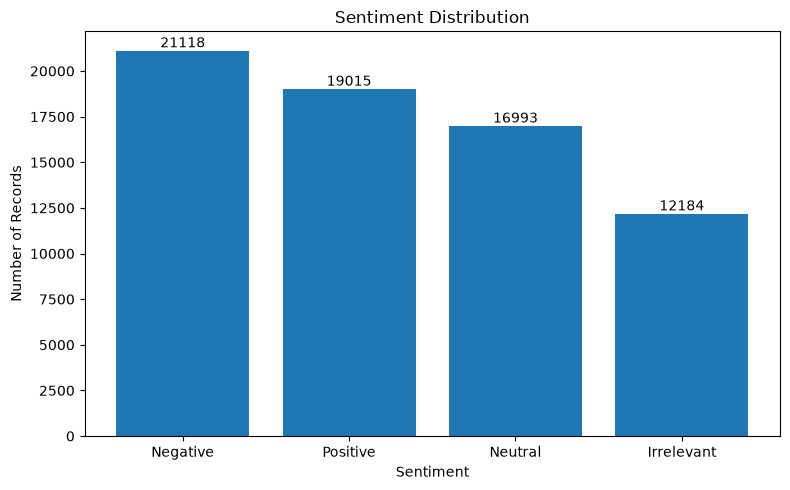

In [54]:
import matplotlib.pyplot as plt

# Count each sentiment class
sentiment_counts = df['label'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values)

# Labels
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Records')

# Show values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

COMMON WORDS

In [55]:
from collections import Counter

all_words = ' '.join(df['regularized_text']).split()

word_freq = Counter(all_words)

word_freq.most_common(20)

[('the', 42612),
 ('i', 35740),
 ('to', 29267),
 ('and', 25805),
 ('a', 23379),
 ('is', 22958),
 ('of', 18877),
 ('for', 15196),
 ('in', 14785),
 ('/', 14586),
 ('it', 14527),
 ('you', 14190),
 ('this', 13404),
 ('.', 12395),
 ('not', 11880),
 ('my', 11479),
 ('on', 11397),
 ('@', 10971),
 ('that', 10166),
 ('with', 8591)]

still we have puncuvations

In [56]:
symbol_tokens = {
    word: count
    for word, count in word_freq.items()
    if not word.isalnum()
}

sorted(symbol_tokens.items(), key=lambda x: x[1], reverse=True)[:20]

[('/', 14586),
 ('.', 12395),
 ('@', 10971),
 ('-', 4615),
 ('&', 3005),
 ('’', 2391),
 ('_', 2218),
 ('it.', 1384),
 ('game.', 1077),
 ('…', 1069),
 ('pic.twitter.com', 867),
 ('(', 649),
 ('=', 637),
 ('|', 637),
 ('me.', 628),
 ('2.', 603),
 (']', 578),
 (')', 567),
 ('"', 547),
 ('t.co', 489)]

In [57]:
df['regularized_text'].str.contains(
    r'https?:|pic\.twitter\.com',
    regex=True,
    na=False
).sum()

np.int64(3064)

In [58]:
df['regularized_text'] = df['regularized_text'].str.replace(
    r'https?:\S*|pic\.twitter\.com\S*',
    '',
    regex=True
)

df['regularized_text'] = df['regularized_text'].str.replace(
    r'\s+',
    ' ',
    regex=True
).str.strip()

In [59]:
df['regularized_text'].str.contains(
    r'https?:|pic\.twitter\.com',
    regex=True,
    na=False
).sum()

np.int64(0)

In [60]:
def final_text_cleaning(text):
    text = str(text)

    # Remove remaining URL artifacts
    text = re.sub(r'https?:\S+|pic\.twitter\.com\S+', '', text)

    # Remove standalone @ symbols
    text = re.sub(r'(?<!\w)@(?=\s|$)', '', text)

    # Remove punctuation except !, ?, and : 
    # : is preserved for emoji descriptions
    text = re.sub(r'[^\w\s!?:]', ' ', text)

    # Remove standalone underscores
    text = re.sub(r'_+', ' ', text)

    # Normalize repeated ! and ?
    text = re.sub(r'([!?])\1+', r'\1', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [61]:
df['regularized_text'] = df['regularized_text'].apply(final_text_cleaning)

In [62]:
empty_count = df['regularized_text'].str.strip().eq('').sum()

print("Empty records:", empty_count)

Empty records: 37


In [63]:
df = df[df['regularized_text'].str.strip().ne('')]
df = df.reset_index(drop=True)

print("Remaining records:", len(df))

Remaining records: 69273


## AGAIN we done text cleaning 

In [64]:
from collections import Counter

all_words = ' '.join(df['regularized_text']).split()
word_freq = Counter(all_words)

word_freq.most_common(20)

[('the', 43362),
 ('i', 36433),
 ('to', 29657),
 ('and', 26176),
 ('a', 23741),
 ('is', 23328),
 ('of', 19108),
 ('it', 17017),
 ('in', 15483),
 ('for', 15429),
 ('you', 15103),
 ('this', 14097),
 ('on', 12133),
 ('not', 12099),
 ('my', 11609),
 ('that', 10656),
 ('with', 8885),
 ('have', 8445),
 ('game', 7856),
 ('are', 7758)]

In [65]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

meaningful_words = [
    word for word in all_words
    if word.lower() not in stop_words
]

meaningful_freq = Counter(meaningful_words)

meaningful_freq.most_common(20)

[('game', 7856),
 ('com', 6453),
 ('like', 4808),
 ('2', 4285),
 ('get', 3885),
 ('one', 3535),
 ('good', 3372),
 ('play', 3359),
 ('new', 3220),
 ('really', 3218),
 ('love', 3145),
 ('johnson', 2977),
 ('cannot', 2896),
 ('people', 2845),
 ('see', 2739),
 ('3', 2736),
 ('going', 2628),
 ('shit', 2582),
 ('best', 2493),
 ('time', 2486)]

still we are seeing com (6453)

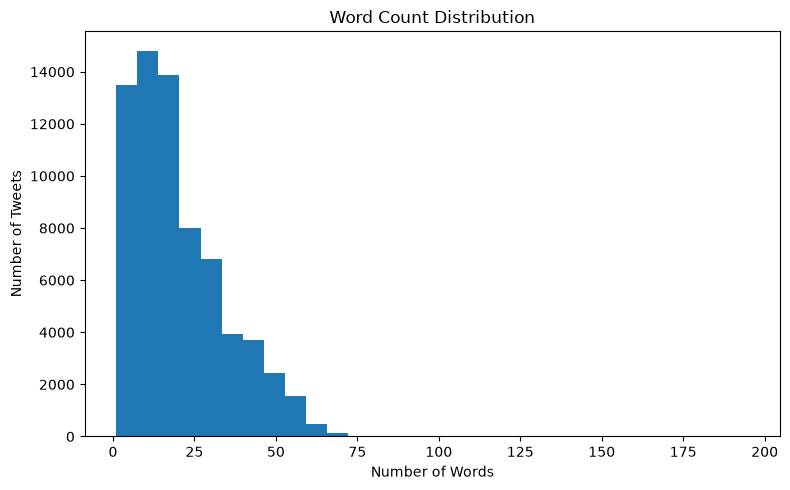

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df['word_count'],
    bins=30
)

plt.title('Word Count Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Number of Tweets')

plt.tight_layout()
plt.show()

In [67]:
df[df['regularized_text'].str.contains(
    r'\bcom\b',
    regex=True,
    na=False
)][['raw_text', 'regularized_text']].head(20)

,raw_text,regularized_text
325,"Borderlands 3: Get, Love, And Tentacles: 10 Be...",borderlands 3 get love and tentacles 10 best n...
396,@GearboxOfficial fix Borderlands 3 achievement...,fix borderlands 3 achievements com this is all...
409,Borderlands 3 - Krieg Meets Maya (Psycho Krieg...,borderlands 3 krieg meets maya psycho krieg an...
410,Borderlands 3 - Krieg Meets Maya (Psycho Krieg...,borderlands 3 krieg meets maya psycho krieg an...
411,Borderlands 3 - Meets Maya (Psycho). youtube.c...,borderlands 3 meets maya psycho youtube com wa...
412,Borderlands Premiere - Krieg Meets Maya and Kr...,borderlands premiere krieg meets maya and krie...
413,Borderlands 3 - Jesse Krieg Music Meets Prince...,borderlands 3 jesse krieg music meets princess...
414,Borderlands Beyond - Scott Meets Me (Psycho Wa...,borderlands beyond scott meets me psycho wave ...
440,Lil preview of a Maya drawing I've been chimin...,lil preview of a maya drawing i have been chim...
456,Have u played borderlands 3? Pretty fun imo. A...,have you played borderlands 3? pretty fun i am...


we are seeing swaggiedeals.com like sites

In [68]:
df['regularized_text'] = df['regularized_text'].str.replace(
    r'\b(?:youtube|twitter|facebook|swaggiedeals|factory)\s+com\b',
    '',
    regex=True
)

basic sites


In [69]:
df['regularized_text'] = df['regularized_text'].str.replace(
    r'\b[\w.-]+\s+com\b',
    '',
    regex=True
)

In [70]:
df['regularized_text'] = df['regularized_text'].str.replace(
    r'\s+',
    ' ',
    regex=True
).str.strip()

In [71]:
df['regularized_text'].str.replace('com', '')

0        i am getting on borderlands and i will murder ...
1          i am ing to the borders and i will kill you all
2        i am getting on borderlands and i will kill yo...
3        i am ing on borderlands and i will murder you all
4        i am getting on borderlands 2 and i will murde...
                               ...                        
69268    just realized that the windows partition of my...
69269    just realized that my mac window partition is ...
69270    just realized the windows partition of my mac ...
69271    just realized between the windows partition of...
69272    just like the windows partition of my mac is l...
Name: regularized_text, Length: 69273, dtype: str

In [72]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

meaningful_words = [
    word for word in all_words
    if word.lower() not in stop_words
]

meaningful_freq = Counter(meaningful_words)

meaningful_freq.most_common(20)

[('game', 7856),
 ('com', 6453),
 ('like', 4808),
 ('2', 4285),
 ('get', 3885),
 ('one', 3535),
 ('good', 3372),
 ('play', 3359),
 ('new', 3220),
 ('really', 3218),
 ('love', 3145),
 ('johnson', 2977),
 ('cannot', 2896),
 ('people', 2845),
 ('see', 2739),
 ('3', 2736),
 ('going', 2628),
 ('shit', 2582),
 ('best', 2493),
 ('time', 2486)]

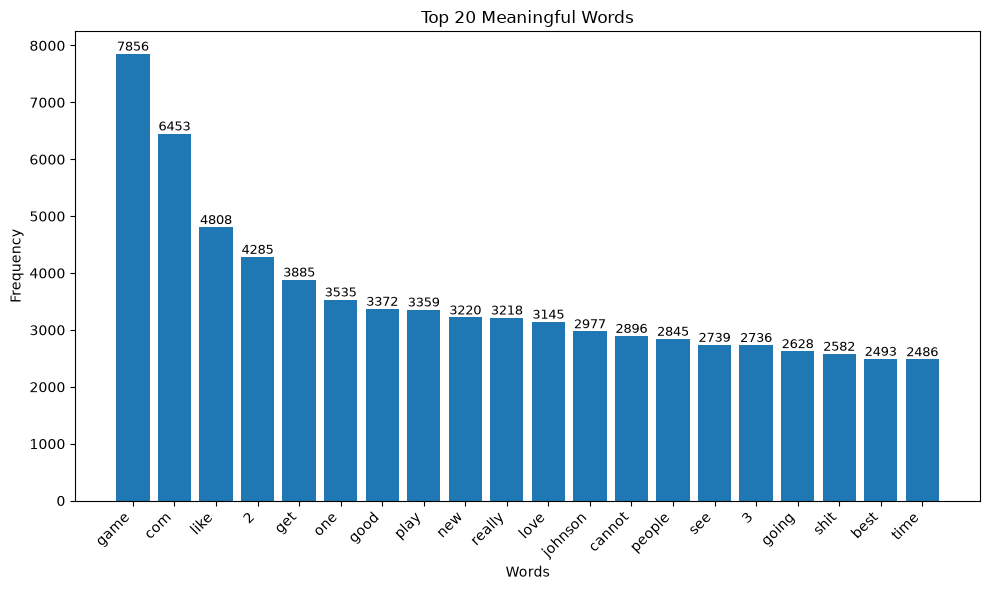

In [73]:
import matplotlib.pyplot as plt

# Get top 20 meaningful words
top_words = meaningful_freq.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 6))

bars = plt.bar(words, counts)

plt.title('Top 20 Meaningful Words')
plt.xlabel('Words')
plt.ylabel('Frequency')

plt.xticks(rotation=45, ha='right')

# Display frequency on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [74]:
df.columns

Index(['label', 'raw_text', 'regularized_text', 'word_count'], dtype='str')

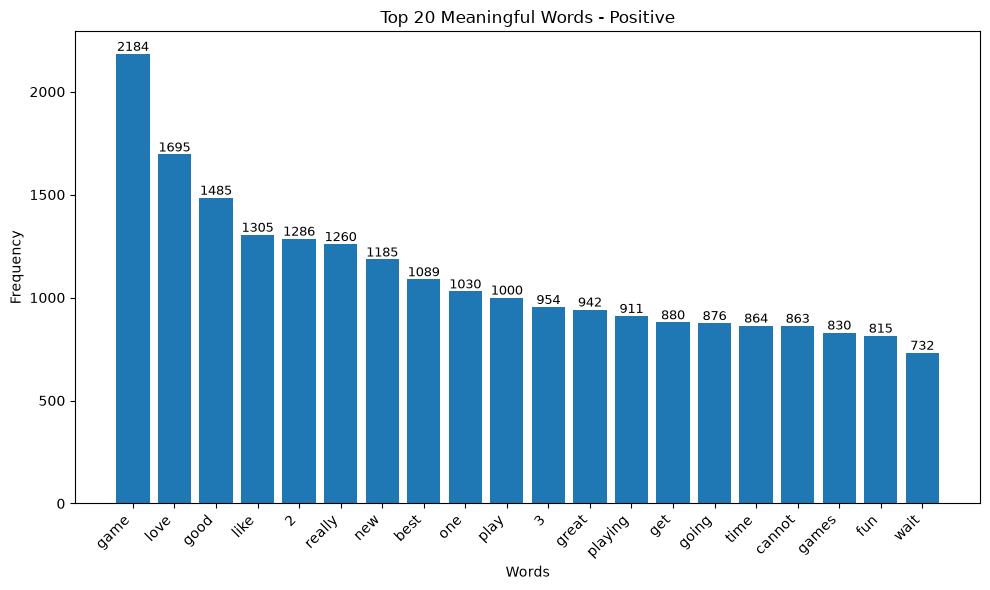

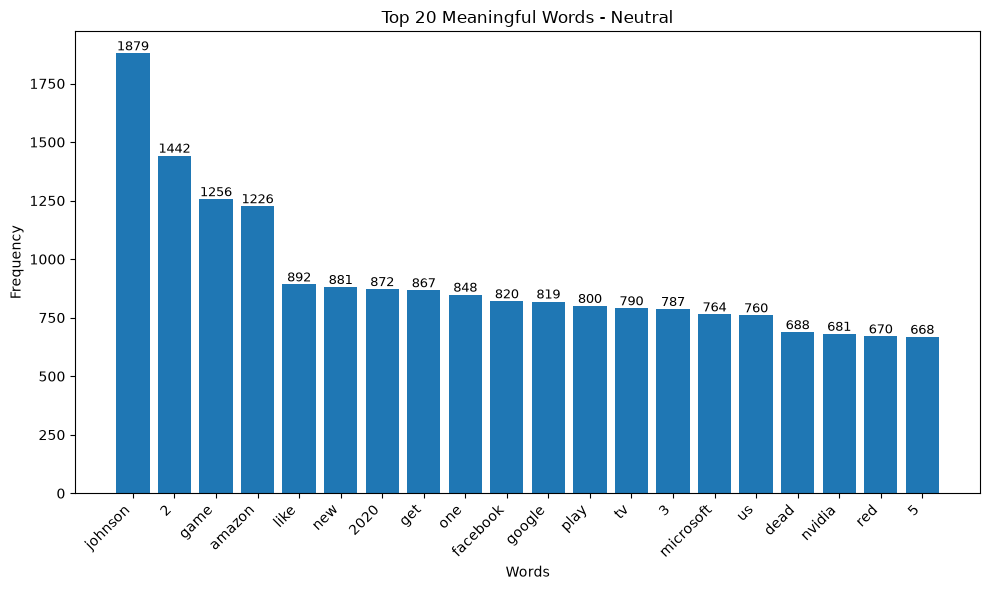

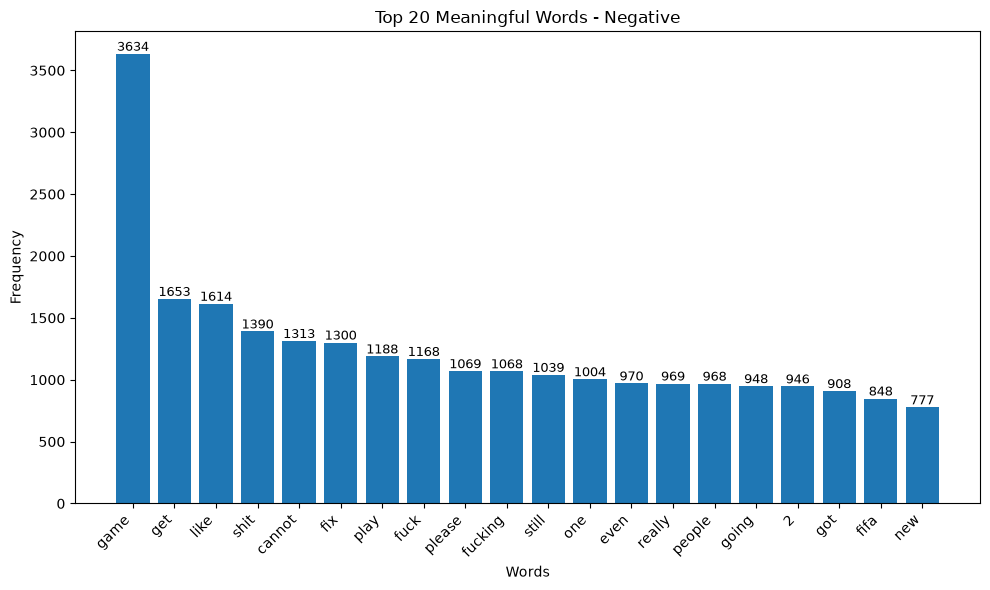

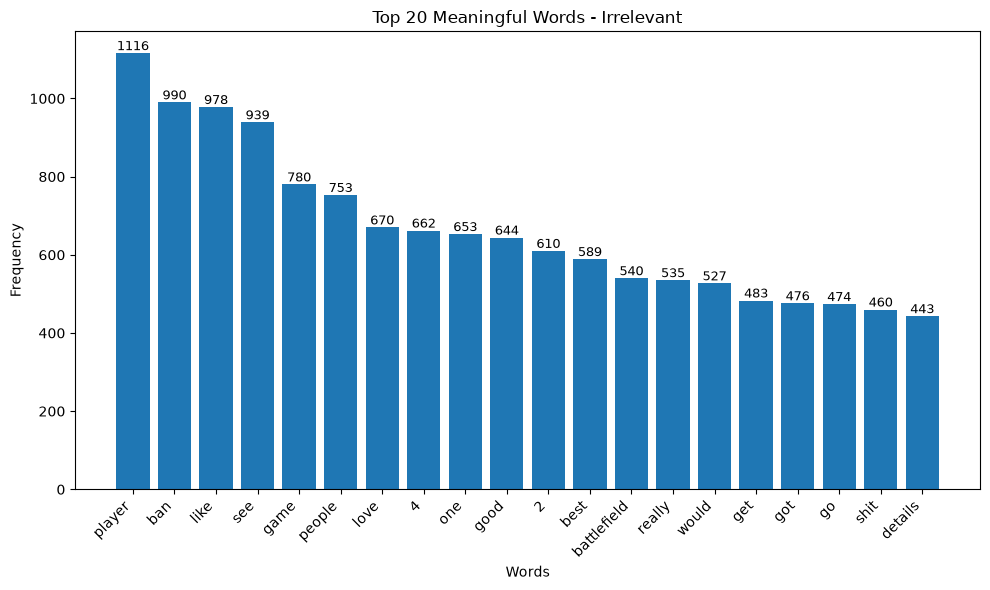

In [75]:
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

stop_words = set(stopwords.words('english'))

labels = df["label"].unique()

for label in labels:

    # Get text for one label
    label_text = df[df["label"] == label]["regularized_text"]

    # Combine all words
    all_words = []

    for text in label_text:
        words = text.split()
        all_words.extend(words)

    # Remove stopwords
    meaningful_words = [
        word for word in all_words
        if word.lower() not in stop_words
    ]

    # Count words
    meaningful_freq = Counter(meaningful_words)

    # Top 20
    top_words = meaningful_freq.most_common(20)

    words = [word for word, count in top_words]
    counts = [count for word, count in top_words]

    # Plot
    plt.figure(figsize=(10, 6))

    bars = plt.bar(words, counts)

    plt.title(f'Top 20 Meaningful Words - {label}')
    plt.xlabel('Words')
    plt.ylabel('Frequency')

    plt.xticks(rotation=45, ha='right')

    # Frequency on bars
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(int(bar.get_height())),
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

In [76]:
johnson_records = df[
    df['regularized_text'].str.contains(
        r'\bjohnson\b',
        case=False,
        regex=True,
        na=False
    )
]

johnson_records[['raw_text', 'regularized_text', 'label']].head(20)

,raw_text,regularized_text,label
672,Watching You Kalloori Perfect Situation Mystic...,watching you kalloori perfect situation mystic...,Positive
674,Watching You Khori Perfect Mystic River Tampa ...,watching you khori perfect mystic river tampa ...,Positive
675,Watching You Kalloori Perfect Situation Mystic...,watching you kalloori perfect situation mystic...,Positive
676,Watching You Jimmy Kalloori Perfect Situation ...,watching you jimmy kalloori perfect situation ...,Positive
677,Watching You Kalloori Perfect Rainbow Mystic R...,watching you kalloori perfect rainbow mystic r...,Positive
10846,@NBA2K suck my dick all you pieces of shit dev...,suck my dick all you pieces of shit developers...,Negative
10847,@ NBA2K suck my dick all you pieces of shit y'...,nba2k suck my dick all you pieces of shit you ...,Negative
10849,@NBA2K suck your dick all you pieces of soul d...,suck your dick all you pieces of soul develope...,Negative
10850,2 @NBA2K and suck my dick and all you pieces o...,2 and suck my dick and all you pieces of shit ...,Negative
10851,@NBA2K suck my dick all you pieces of shit my ...,suck my dick all you pieces of shit my you all...,Negative


In [77]:
johnson_records['label'].value_counts()

label
Neutral       912
Negative      404
Positive      165
Irrelevant      1
Name: count, dtype: int64

In [78]:
df.head()

,label,raw_text,regularized_text,word_count
0,Positive,im getting on borderlands and i will murder yo...,i am getting on borderlands and i will murder ...,12
1,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,12
2,Positive,im getting on borderlands and i will kill you ...,i am getting on borderlands and i will kill yo...,11
3,Positive,im coming on borderlands and i will murder you...,i am coming on borderlands and i will murder y...,11
4,Positive,im getting on borderlands 2 and i will murder ...,i am getting on borderlands 2 and i will murde...,13


## N-gram analysis

Unigram → Bigram → Trigram

An N-gram is a sequence of N consecutive words from a sentence.

- "good"          → positive
- "not good"      → negative
- "very good"     → strongly positive
- "not very good" → negative

bigram

In [79]:
from collections import Counter
from nltk.util import ngrams

bigram_freq = Counter()

for text in df['regularized_text']:
    words = text.split()
    bigram_freq.update(ngrams(words, 2))

bigram_freq.most_common(20)

[(('i', 'am'), 6207),
 (('it', 'is'), 4141),
 (('i', 'have'), 3250),
 (('do', 'not'), 3027),
 (('of', 'the'), 2818),
 (('in', 'the'), 2789),
 (('and', 'i'), 2210),
 (('this', 'is'), 2034),
 (('is', 'a'), 1836),
 (('for', 'the'), 1823),
 (('on', 'the'), 1806),
 (('to', 'be'), 1693),
 (('the', 'game'), 1692),
 (('going', 'to'), 1685),
 (('red', 'dead'), 1418),
 (('to', 'the'), 1413),
 (('you', 'are'), 1327),
 (('is', 'the'), 1319),
 (('the', 'best'), 1301),
 (('i', 'love'), 1249)]

In [80]:
meaningful_bigrams = Counter()

for text in df['regularized_text']:
    words = [
        word for word in text.split()
        if word.lower() not in stop_words
    ]
    meaningful_bigrams.update(ngrams(words, 2))

meaningful_bigrams.most_common(20)

[(('red', 'dead'), 1443),
 (('johnson', 'johnson'), 1222),
 (('twitch', 'tv'), 1146),
 (('dead', 'redemption'), 1129),
 (('home', 'depot'), 940),
 (('call', 'duty'), 853),
 (('rhandlerr', 'rhandlerr'), 782),
 (('redemption', '2'), 721),
 (('xbox', 'series'), 699),
 (('cannot', 'wait'), 688),
 (('series', 'x'), 671),
 (('league', 'legends'), 619),
 (('dota', '2'), 546),
 (('https', 'co'), 540),
 (('battlefield', '4'), 525),
 (('let', 'us'), 519),
 (('black', 'ops'), 498),
 (('borderlands', '3'), 496),
 (('assassin', 'creed'), 475),
 (('player', 'ban'), 471)]

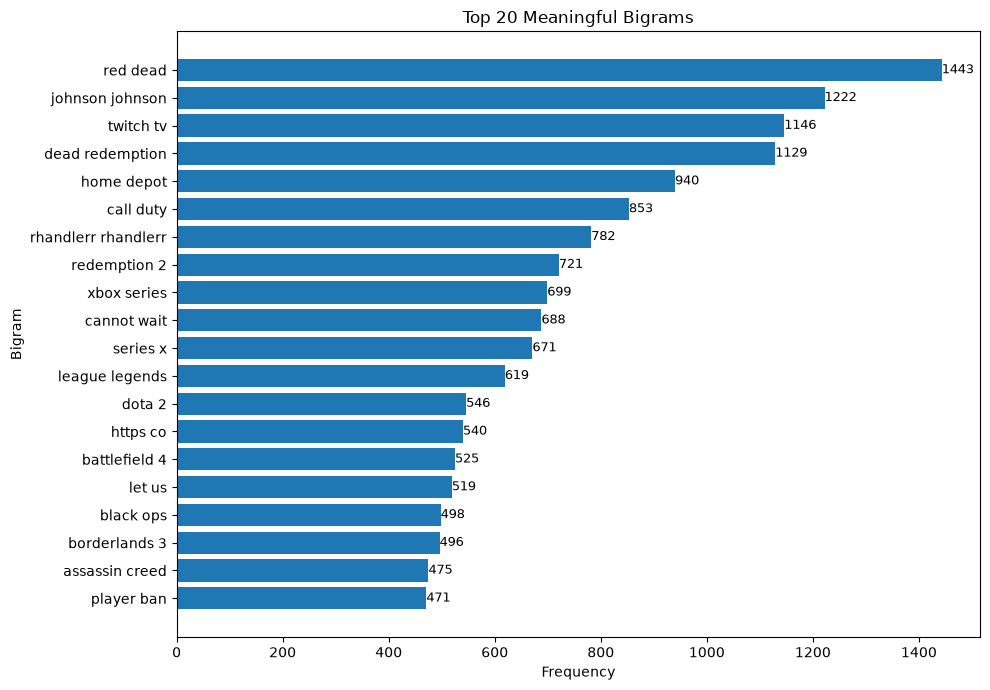

In [81]:
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Keep bigrams where both words are meaningful
meaningful_bigrams = Counter()

for text in df['regularized_text']:
    words = text.split()

    # Remove stopwords only for EDA
    words = [word for word in words if word.lower() not in stop_words]

    meaningful_bigrams.update(ngrams(words, 2))

# Top 20 meaningful bigrams
top_bigrams = meaningful_bigrams.most_common(20)

bigrams = [' '.join(bigram) for bigram, count in top_bigrams]
counts = [count for bigram, count in top_bigrams]

# Plot
plt.figure(figsize=(10, 7))

bars = plt.barh(bigrams[::-1], counts[::-1])

plt.title('Top 20 Meaningful Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')

# Add frequency values
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

observation : most of bigrams are about games

In [82]:
df[df['regularized_text'].str.contains(
    r'\brhandlerr\b',
    case=False,
    regex=True,
    na=False
)][['raw_text', 'regularized_text', 'label']].head(20)

,raw_text,regularized_text,label
9,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...,Positive
10,2010 So I spent a few hours making something f...,2010 so i spent a few hours making something f...,Positive
366,Pretty Happy with this! I made these sub badge...,pretty happy with this! i made these sub badge...,Irrelevant
367,i Pretty Happy with this! I made these sub bad...,i pretty happy with this! i made these sub bad...,Irrelevant
407,Yasss!!! Co-Stream with RhandlerR twitch.tv/j...,yasss! co stream with rhandlerr twitch tv jimm...,Irrelevant
408,2 Yasss!!! Co-Stream with RhandlerR twitch.tv...,2 yasss! co stream with rhandlerr twitch tv ji...,Irrelevant
430,Loving the new DLC!!!. RhandlerR RhandlerR Rha...,loving the new dlc! rhandlerr rhandlerr rhandlerr,Positive
431,F Loving the new DLC!!!. RhandlerR RhandlerR R...,f loving the new dlc! rhandlerr rhandlerr rhan...,Positive
485,I know it doesnt look like much but borderland...,i know it does not look like much but borderla...,Positive
486,N I know it doesnt look like much but borderla...,n i know it does not look like much but border...,Positive


we are seeing repeated words

In [83]:
# def remove_repeated_words(text):
#     return re.sub(r'\b(\w+)(?:\s+\1\b)+', r'\1', text, flags=re.IGNORECASE)

In [84]:
# df['regularized_text'] = df['regularized_text'].apply(remove_repeated_words)

In [85]:
# df[df['regularized_text'].str.contains(
#     r'\brhandlerr\b',
#     case=False,
#     regex=True,
#     na=False
# )][['raw_text', 'regularized_text', 'label']].head(20)

## trigram

In [86]:
trigram_freq = Counter()

for text in df['regularized_text']:
    words = text.split()
    trigram_freq.update(ngrams(words, 3))

trigram_freq.most_common(20)

[(('i', 'do', 'not'), 1037),
 (('red', 'dead', 'redemption'), 1005),
 (('call', 'of', 'duty'), 780),
 (('dead', 'redemption', '2'), 651),
 (('league', 'of', 'legends'), 590),
 (('xbox', 'series', 'x'), 552),
 (('https', 't', 'co'), 489),
 (('i', 'have', 'been'), 448),
 (('assassin', 's', 'creed'), 448),
 (('i', 'am', 'so'), 435),
 (('rhandlerr', 'rhandlerr', 'rhandlerr'), 432),
 (('and', 'i', 'am'), 423),
 (('i', 'am', 'going'), 398),
 (('i', 'am', 'not'), 395),
 (('do', 'not', 'know'), 390),
 (('a', 'lot', 'of'), 372),
 (('am', 'going', 'to'), 370),
 (('one', 'of', 'the'), 361),
 (('going', 'to', 'be'), 360),
 (('it', 'is', 'a'), 358)]

In [87]:
import matplotlib.pyplot as plt
from collections import Counter
from nltk.util import ngrams
from nltk.corpus import stopwords


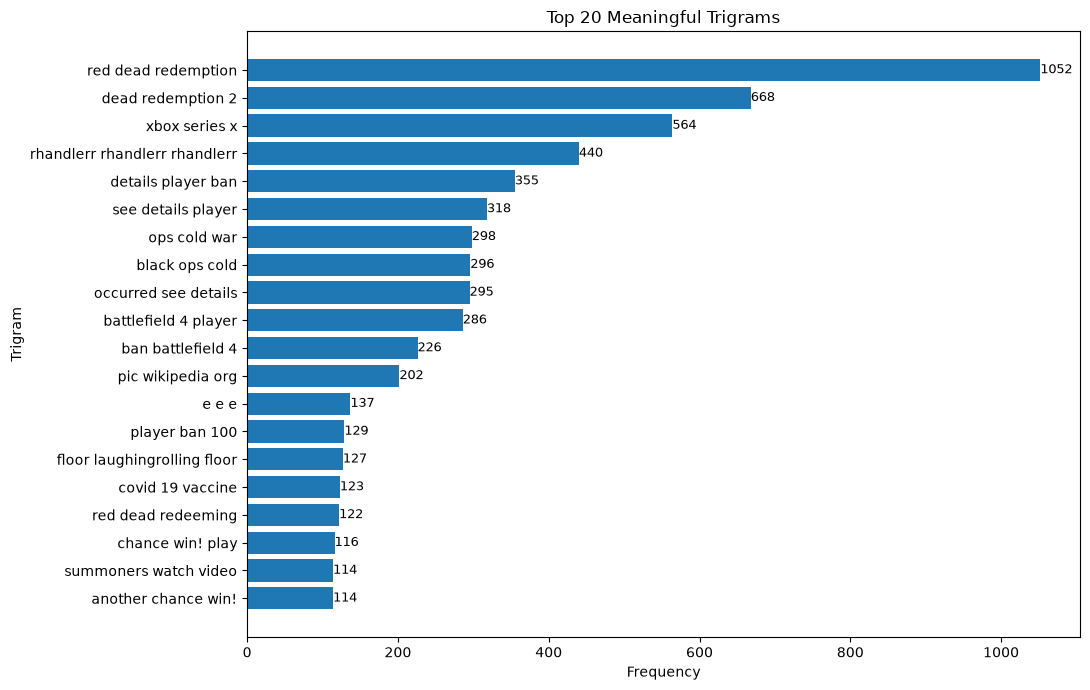

In [88]:

stop_words = set(stopwords.words('english'))

meaningful_trigrams = Counter()

for text in df['regularized_text']:
    words = text.split()

    # Remove stopwords for EDA
    words = [word for word in words if word.lower() not in stop_words]

    # Create trigrams
    meaningful_trigrams.update(ngrams(words, 3))

# Top 20 meaningful trigrams
top_trigrams = meaningful_trigrams.most_common(20)

trigrams = [' '.join(trigram) for trigram, count in top_trigrams]
counts = [count for trigram, count in top_trigrams]

# Plot
plt.figure(figsize=(11, 7))

bars = plt.barh(trigrams[::-1], counts[::-1])

plt.title('Top 20 Meaningful Trigrams')
plt.xlabel('Frequency')
plt.ylabel('Trigram')

# Add frequency values
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [89]:
# !pip install contractions

In [90]:
# import contractions

# def expand_contractions(text):
#     return contractions.fix(str(text))

# df['regularized_text'] = df['regularized_text'].apply(expand_contractions)

In [91]:
# df[df['regularized_text'].str.contains(
#     r"\bi\s*(?:m|ve)\b|\bit\s*s\b",
#     case=False,
#     regex=True,
#     na=False
# )][['raw_text', 'regularized_text']].head(20)

we seen contraction must be handled before punctuations

## We should split the dataset before fitting the tokenizer to avoid data leakage.

dl we--split Train, Validation, and Test.

In [92]:
df.head()

,label,raw_text,regularized_text,word_count
0,Positive,im getting on borderlands and i will murder yo...,i am getting on borderlands and i will murder ...,12
1,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,12
2,Positive,im getting on borderlands and i will kill you ...,i am getting on borderlands and i will kill yo...,11
3,Positive,im coming on borderlands and i will murder you...,i am coming on borderlands and i will murder y...,11
4,Positive,im getting on borderlands 2 and i will murder ...,i am getting on borderlands 2 and i will murde...,13


In [93]:
# Save the processed dataset as a new CSV
df.to_csv('twitter_training_cleaned.csv', index=False)

print("Saved successfully!")

Saved successfully!


In [94]:
df_check = pd.read_csv('twitter_training_cleaned.csv')

print(df_check.shape)
print(df_check.columns)
print(df_check['label'].value_counts())

(69273, 4)
Index(['label', 'raw_text', 'regularized_text', 'word_count'], dtype='str')
label
Negative      21109
Positive      19012
Neutral       16977
Irrelevant    12175
Name: count, dtype: int64


In [95]:
# Keep only the columns needed for the NLP model
model_df = df[['label', 'regularized_text']].copy()

# Save as a new CSV
model_df.to_csv('twitter_training_model.csv', index=False)

print("Saved successfully!")
print(model_df.shape)
print(model_df.head())

Saved successfully!
(69273, 2)
      label                                   regularized_text
0  Positive  i am getting on borderlands and i will murder ...
1  Positive  i am coming to the borders and i will kill you...
2  Positive  i am getting on borderlands and i will kill yo...
3  Positive  i am coming on borderlands and i will murder y...
4  Positive  i am getting on borderlands 2 and i will murde...


In [96]:
print(df.isna().sum())


label               0
raw_text            0
regularized_text    0
word_count          0
dtype: int64


In [97]:
print("NaN values:", df['regularized_text'].isna().sum())

NaN values: 0


In [98]:
df[df['regularized_text'].isna()]

,label,raw_text,regularized_text,word_count


In [99]:
print("Total NaN values:", df.isna().sum().sum())

Total NaN values: 0


In [100]:
df['regularized_text'].isna().sum()

np.int64(0)

In [101]:
print(df['regularized_text'].isna().sum())
print(df['regularized_text'].dtype)
print(df.shape)

0
str
(69273, 4)


In [102]:
import os

print(os.path.abspath('twitter_training_model.csv'))

c:\Users\sudhe\OneDrive\Desktop\Sentiment Analysis\neew\twitter_training_model.csv


In [103]:
df['regularized_text'][26383]

''

In [104]:
print("NaN:", df['regularized_text'].isna().sum())

print("Non-string:", 
      (~df['regularized_text'].apply(lambda x: isinstance(x, str))).sum())

print("Whitespace-only:", 
      df['regularized_text'].str.strip().eq('').sum())

NaN: 0
Non-string: 0
Whitespace-only: 3


In [105]:
df = df[df['regularized_text'].str.strip().ne('')].reset_index(drop=True)

In [106]:
model_df = df[['label', 'regularized_text']].copy()

# Save as a new CSV
model_df.to_csv('twitter_training_model.csv', index=False)

print("Saved successfully!")
print(model_df.shape)
print(model_df.head())

Saved successfully!
(69270, 2)
      label                                   regularized_text
0  Positive  i am getting on borderlands and i will murder ...
1  Positive  i am coming to the borders and i will kill you...
2  Positive  i am getting on borderlands and i will kill yo...
3  Positive  i am coming on borderlands and i will murder y...
4  Positive  i am getting on borderlands 2 and i will murde...
